In [1]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


In [12]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
        debug_shapes (bool): print assembled tensor shapes before solve
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=6.0e2, debug_shapes=False):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.debug_shapes = debug_shapes

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading,
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        if self.debug_shapes:
            print("--- SolveStrain shape debug ---")
            print(f"time shape: {tuple(time.shape)}")
            print(f"temperature shape: {tuple(temperature.shape)}")
            print(f"loading shape: {tuple(loading.shape)}")
            print(f"control shape: {tuple(control.shape)}")
            print(f"assembled forces shape: {tuple(forces.shape)}")
            print(f"assembled state0 shape: {tuple(state0.shape)}")
            print(f"len(forces): {len(forces)}")
            print(f"nchunk: {self.nchunk}")

            try:
                force_parts = self.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(forces, 2))
                print("forces_asm split shapes:")
                for name, value in force_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"forces_asm split failed: {e}")

            try:
                state_parts = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(state0, 1))
                print("state_asm split shapes:")
                for name, value in state_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"state_asm split failed: {e}")

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

In [13]:
nmodel = neml2.load_model("new_model_tensile.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_a", "E_b", "E_c", "G_A", "G_bottom_A", "athermal_alpha", "athermal_b",
                                                                            "nu_a", "nu_b", "nu_c", "flow_rate_b", "shear_eff_m", "yield_sy", "v_disl_p",
                                                                            "v_disl_q", "v_disl_tau_p", "v_disl_H_0", "v_disl_s"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: E_a [Scalar][Double][cuda:0]
            E_b [Scalar][Double][cuda:0]
            E_c [Scalar][Double][cuda:0]
            G_A [Scalar][Double][cuda:0]
            G_bottom_A [Scalar][Double][cuda:0]
            athermal_alpha [Scalar][Double][cuda:0]
            athermal_b [Scalar][Double][cuda:0]
            flow_rate_b [Scalar][Double][cuda:0]
         

723K, 9.26e-05 1/s: strain range [0.0000, 0.0230]
523K, 9.26e-05 1/s: strain range [0.0000, 0.0523]
573K, 9.26e-05 1/s: strain range [0.0000, 0.0296]


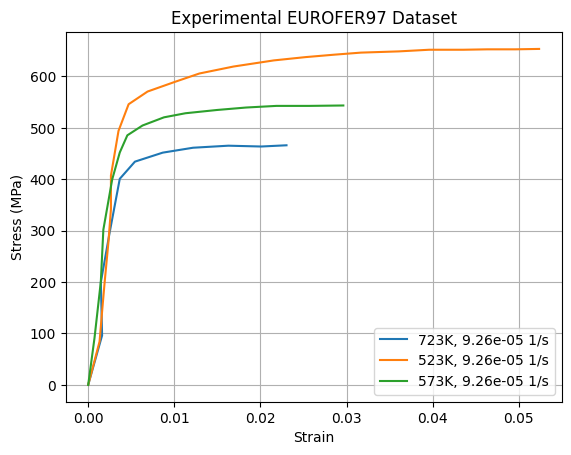

In [14]:
# Load experimental data
path = '/home/colinmg/neml2/cmg_projects/stress-strain/tensile_data/EUROFER97'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if '523' in filename:
            temp = 523
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        elif '573' in filename:
            temp = 573
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        elif '723' in filename:
            temp = 723
            strain_rate = 9.259e-5
            label = f'{temp}K, {strain_rate:.2e} 1/s'
        else:
            label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{label}_strain', 'y':f'{label}_stress'})
        data_frames[label] = new_df

strain_data = {}
stress_data = {}

for label, df in data_frames.items():
    strain_col = f'{label}_strain'
    stress_col = f'{label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[label] = strain
    stress_data[label] = stress

exp_conditions = []
for label, df in data_frames.items():
    temp_str = label.split(',')[0]
    strain_rate_str = label.split(',')[1]

    temp = float(temp_str.replace('K', '').strip())
    strain_rate = float(strain_rate_str.replace('1/s', '').strip())
    exp_conditions.append((temp, strain_rate, label))

for i, (temp, rate, label) in enumerate(exp_conditions):
    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    # Experimental strain ranges
    print(f"{label}: strain range [{min_strain:.4f}, {max_strain:.4f}]")

# Plot initial dataset
plt.figure()
for label in strain_data:
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(), label=label)
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental EUROFER97 Dataset')
plt.grid()
plt.legend()
plt.show()

In [15]:
ntemperature = len(exp_conditions[0])
nrate = len(exp_conditions[1])
nbatch = len(exp_conditions)
ntime = 200
temperatures = torch.tensor([c[0] for c in exp_conditions], device=device)
rates = torch.tensor([c[1] for c in exp_conditions], device=device)

print(f"--- Initial Experimental Conditions ---\nstrain rates:\n{rates}\ntemperatures (K):\n{temperatures}")


--- Initial Experimental Conditions ---
strain rates:
tensor([9.2600e-05, 9.2600e-05, 9.2600e-05], device='cuda:0')
temperatures (K):
tensor([723., 523., 573.], device='cuda:0')


In [16]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (temp, rate, label) in enumerate(exp_conditions):

    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    print(f"Temperature = {temp}K, rate = {rate:.2e} 1/s: strain range [{min_strain:.4f}, {max_strain:.4f}]")
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rate, ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = temp

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


Temperature = 723.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0230]
Temperature = 523.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0523]
Temperature = 573.0K, rate = 9.26e-05 1/s: strain range [0.0000, 0.0296]

--- Full Input Tensors ---
time: torch.Size([200, 3, 1])
temperature: torch.Size([200, 3, 1])
loading: torch.Size([200, 3, 6])


Initial data size for 723K, 9.26e-05 1/s: torch.Size([11])
Initial data size for 523K, 9.26e-05 1/s: torch.Size([23])
Initial data size for 573K, 9.26e-05 1/s: torch.Size([15])
Interpolated data shape:
strain: torch.Size([200, 3, 6])
stress: torch.Size([200, 3, 6])
Saturated Stress values
[466.0039761431413, 653.386454183267, 543.3962264150944]


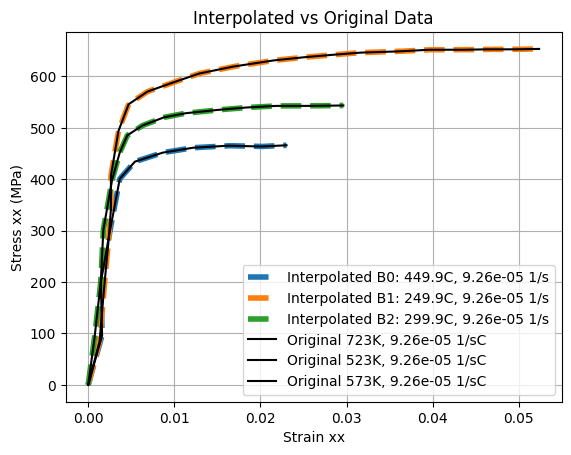

In [17]:
# Initial data shape
for label in strain_data:
    print(f"Initial data size for {label}: {stress_data[label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, (temp, rate, label) in enumerate(exp_conditions):
    
    f_strain = torch.nn.functional.interpolate(strain_data[label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
print(f"{[exp_stress_data[-1, i, 0].item() for i, _ in enumerate(temperatures)]:}")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {label}")
for label in strain_data:
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(), color='k', label=f"Original {label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


In [18]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[0.0000e+00],
         [0.0000e+00],
         [0.0000e+00]],

        [[1.7998e-03],
         [9.3739e-02],
         [2.7079e-02]],

        [[3.6684e-03],
         [1.9113e-01],
         [5.5125e-02]],

        [[5.6055e-03],
         [2.9216e-01],
         [8.4134e-02]],

        [[7.6111e-03],
         [3.9681e-01],
         [1.1410e-01]],

        [[9.6851e-03],
         [5.0507e-01],
         [1.4502e-01]],

        [[1.1827e-02],
         [6.1693e-01],
         [1.7690e-01]],

        [[1.4037e-02],
         [7.3238e-01],
         [2.0972e-01]],

        [[1.6316e-02],
         [8.5141e-01],
         [2.4348e-01]],

        [[1.8662e-02],
         [9.7401e-01],
         [2.7819e-01]],

        [[2.1076e-02],
         [1.1002e+00],
         [3.1384e-01]],

        [[2.3558e-02],
         [1.2299e+00],
         [3.5042e-01]],

        [[2.6107e-02],
         [1.3631e+00],
         [3.8794e-01]],

        [[2.8724e-02],
         [1.4999e+00],
         [4.2640e-01]],

      

Text(0.5, 1.0, 'Initial Comparison')

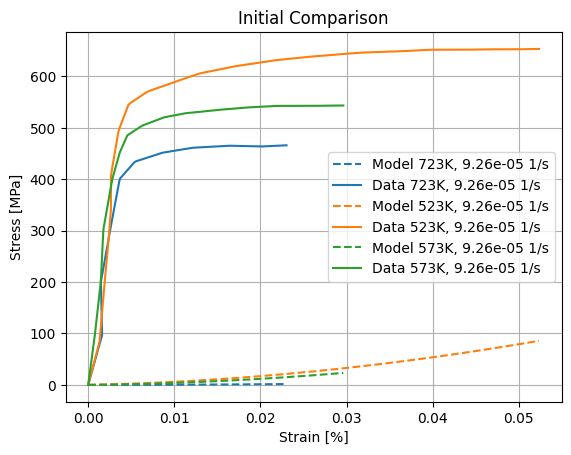

In [19]:
for i, (temp, rate, label) in enumerate(exp_conditions):
    plt.plot(loading[:, i, 0].detach().cpu(), stress[:, i, 0].detach().cpu(), '--', color=f'C{i}',label=f'Model {label}')
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), color=f'C{i}',label=f'Data {label}')
plt.xlabel("Strain [%]")
plt.ylabel("Stress [MPa]")
plt.legend()
plt.grid()
plt.title("Initial Comparison")


In [20]:
# Debug: inspect internal-variable evolution over time; overlay all batches on two 2x2 figures
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

forces_hist_raw = model.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(dbg_forces, 1))
forces_hist = {str(k): v.torch() for k, v in forces_hist_raw.items()}

state_names = sorted(state_hist.keys())
print("Available state variables:")
for name in state_names:
    print(" ", name)

forces_names = sorted(forces_hist.keys())
print("Available force variables:")
for name in forces_names:
    print(" ", name)

def get_hist(axis, name):
    return axis[name].torch() if name in state_hist else None

T_in_forces = forces_hist["forces/T"]
E_a = nmodel.E_a.torch().item(); E_b = nmodel.E_b.torch().item(); E_c = nmodel.E_c.torch().item()
nu_a = nmodel.nu_a.torch().item(); nu_b = nmodel.nu_b.torch().item(); nu_c = nmodel.nu_c.torch().item()

alpha = nmodel.athermal_alpha.tensor()
b = nmodel.athermal_b.tensor()
init_rho_m = model.initial_rho_m
L_init = 1 / np.sqrt(init_rho_m)

print(f"\n{'Batch':>5}  {'T_f (expected)':>16}  {'T_f in forces/T':>17}  {'Match':>7}  {'E':>10}  {'nu':>10}  {'G':>10}  {'sigma_a':>10}")
for i, (T_f, rate) in enumerate(batch_conditions):
    T_first = T_in_forces[0,  i, 0].item()
    T_last  = T_in_forces[-1, i, 0].item()
    match = "✓" if abs(T_first - T_f) == 0 and abs(T_last - T_f) == 0 else "✗ MISMATCH"
    E = E_a * T_f**2 + E_b * T_f + E_c
    nu = nu_a * T_f**2 + nu_b * T_f + nu_c
    G = E / (2.0 * (1.0 + nu))
    sigma_a = (alpha * G * b) / L_init

    print(f"  {i:>3}  {T_f:>16.2f}  {T_first:>17.2f}  {match:>7}  {E:>10.2f}  {nu:>10.3f}  {G:>10.2f}  {sigma_a.item():>10.2f}")

rho_m = get_hist(state_hist, "state/internal/rho_m")
X = get_hist(state_hist, "state/internal/X")

fig_s, ax_s = plt.subplots(1, 3, figsize=(20, 9))
fig_s.suptitle("State Evolution Across Batches in Strain")

fig_t, ax_t = plt.subplots(1, 3, figsize=(20, 9))
fig_t.suptitle("State Evolution Across Batches in Time")

for i, T in enumerate(temperatures):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None

    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={temp_c:.1f}C, rate={rate_i:.3e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax_s[0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
        ax_t[0].plot(time_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax_s[1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
        ax_t[1].plot(time_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax_s[2].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
        ax_t[2].plot(time_hist.numpy(), x_norm_hist.numpy(), label=label)

ax_s[0].set_title("mixed_state vs strain")
ax_s[0].set_xlabel("Strain")
ax_s[0].set_ylabel("Stress [MPa]")
ax_s[0].grid(True)
ax_s[0].legend(fontsize=8)

ax_s[1].set_title("rho_m vs strain")
ax_s[1].set_xlabel("Strain")
ax_s[1].set_ylabel("rho_m")
ax_s[1].grid(True)
ax_s[1].legend(fontsize=8)

ax_s[2].set_title("||X|| vs strain")
ax_s[2].set_xlabel("Strain")
ax_s[2].set_ylabel("||X||")
ax_s[2].grid(True)
ax_s[2].legend(fontsize=8)

ax_t[0].set_title("mixed_state vs time")
ax_t[0].set_xlabel("Time [s]")
ax_t[0].set_ylabel("Stress [MPa]")
ax_t[0].grid(True)
ax_t[0].legend(fontsize=8)

ax_t[1].set_title("rho_m vs time")
ax_t[1].set_xlabel("Time [s]")
ax_t[1].set_ylabel("rho_m")
ax_t[1].grid(True)
ax_t[1].legend(fontsize=8)

ax_t[2].set_title("||X|| vs time")
ax_t[2].set_xlabel("Time [s]")
ax_t[2].set_ylabel("||X||")
ax_t[2].grid(True)
ax_t[2].legend(fontsize=8)

fig_s.tight_layout()
fig_t.tight_layout()
plt.show()

/home/colinmg/anaconda3/envs/neml2/lib/python3.12/site-packages/pyzag/chunktime.py:114: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


KeyboardInterrupt: 

In [96]:
k1 = nmodel.k1_Y.tensor().torch()
k2 = nmodel.k2_Y.tensor().torch()
rho_m_ss = (k1 / k2)**2
print(f"k1 = {k1}")
print(f"k2 = {k2}")
print(f"Predicted steady-state rho_m = {rho_m_ss}")
print(f"Initial rho_m = {model.initial_rho_m}")
print(f"Ratio (rho_m_ss / rho_m_init) = {rho_m_ss / model.initial_rho_m}")

k1 = tensor([100000000., 100000000., 100000000., 100000000.], device='cuda:0')
k2 = tensor([21., 21., 21., 21.], device='cuda:0')
Predicted steady-state rho_m = tensor([2.2676e+13, 2.2676e+13, 2.2676e+13, 2.2676e+13], device='cuda:0')
Initial rho_m = 1000000000000.0
Ratio (rho_m_ss / rho_m_init) = tensor([22.6757, 22.6757, 22.6757, 22.6757], device='cuda:0')


In [97]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([0.0001, 0.0001, 0.0001, 0.0001], device='cuda:0'), torch.Size([4])

discrete_equations.C_Y: tensor([46600., 27000., 21750.,  4300.], device='cuda:0'), torch.Size([4])

discrete_equations.H_0_Y: tensor([0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0'), torch.Size([4])

discrete_equations.T_0_Y: tensor([234.5200, 631.3200, 715.3200, 778.5200], device='cuda:0'), torch.Size([4])

discrete_equations.g_Y: tensor([50., 50., 50., 50.], device='cuda:0'), torch.Size([4])

discrete_equations.k1_Y: tensor([100000000., 100000000., 100000000., 100000000.], device='cuda:0'), torch.Size([4])

discrete_equations.k2_Y: tensor([21., 21., 21., 21.], device='cuda:0'), torch.Size([4])



In [ ]:
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8], device=device), torch.tensor([5.0e-3, 5.0e-3, 5.0e-3, 5.0e-3], device=device))
C_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0, 100.0], device=device), torch.tensor([50000.0, 50000.0, 50000.0, 50000.0], device=device))
H_0_scaler = reparametrization.RangeRescale(torch.tensor([0.1, 0.1, 0.1, 0.1], device=device), torch.tensor([2.0, 2.0, 2.0, 2.0], device=device))
T_0_scaler = reparametrization.RangeRescale(torch.tensor([100.0, 100.0, 100.0, 100.0], device=device), torch.tensor([5000.0, 5000.0, 5000.0, 5000.0], device=device))
g_scaler = reparametrization.RangeRescale(torch.tensor([0.01, 0.01, 0.01, 0.01], device=device), torch.tensor([500.0, 500.0, 500.0, 500.0], device=device))
k1_scaler = reparametrization.RangeRescale(torch.tensor([1.0e6, 1.0e6, 1.0e6, 1.0e6], device=device), torch.tensor([1.0e9, 1.0e9, 1.0e9, 1.0e9], device=device))
k2_scaler = reparametrization.RangeRescale(torch.tensor([5.0, 5.0, 5.0, 5.0], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))

model_reparameterizer = reparametrization.Reparameterizer(
    {"discrete_equations.Bk_Y": Bk_scaler,
     "discrete_equations.C_Y": C_scaler,
     "discrete_equations.H_0_Y": H_0_scaler,
     "discrete_equations.T_0_Y": T_0_scaler,
     "discrete_equations.g_Y": g_scaler,
     "discrete_equations.k1_Y": k1_scaler,
     "discrete_equations.k2_Y": k2_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.Bk_Y.original: tensor([0.0200, 0.0200, 0.0200, 0.0200], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.C_Y.original: tensor([0.9319, 0.5391, 0.4339, 0.0842], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.H_0_Y.original: tensor([0.2105, 0.2105, 0.2105, 0.2105], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.T_0_Y.original: tensor([0.0275, 0.1084, 0.1256, 0.1385], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.g_Y.original: tensor([0.1000, 0.1000, 0.1000, 0.1000], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k1_Y.original: tensor([0.0040, 0.0040, 0.0040, 0.0040], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k2_Y.original: tensor([0.1998, 0.1998, 0.1998, 0.1998], device='cuda:0'), requires_grad=True


Loss: 1.93e-02: :  83%|████████▎ |833/1000/home/colinmoose/miniforge/envs/neml2/lib/python3.13/site-packages/pyzag/chunktime.py:114: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(
Loss: 1.53e-02: : 100%|██████████|1000/1000


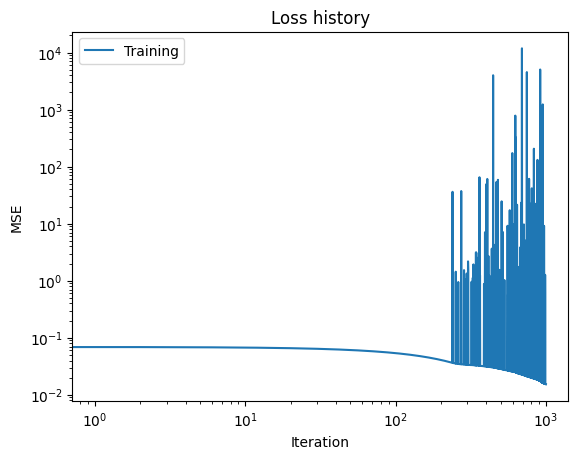

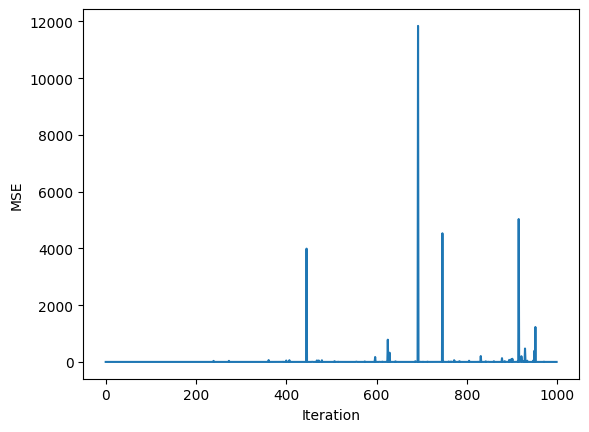

In [67]:
niter = 1000
sensitive_params = ['discrete_equations.parametrizations.Bk_Y.original',
                    'discrete_equations.parametrizations.H_0_Y.original',
                    'discrete_equations.parametrizations.T_0_Y.original']

param_groups = []
for n, p in model.named_parameters():
    if any(fp in n for fp in sensitive_params):
        param_groups.append({'params': [p], 'lr': 1e-5})
    else:
        param_groups.append({'params': [p], 'lr': 1e-4})

optimizer = torch.optim.Adam(param_groups)
loss_fn = torch.nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-7)

peak_stress = exp_stress_data[-1,:,0:1].detach()

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    optimizer.zero_grad()
    try:
        res = model(time, temperature, loading)
        res_norm = res / (peak_stress + 1e-8)
        exp_norm = exp_stress_data[...,0:1] / (peak_stress + 1e-8)
        loss = loss_fn(res_norm, exp_norm)
        if not torch.isfinite(loss) or loss.item() > 1e6:
            titer.set_description(f'Loss: [SKIP bad solve @ iter {i}]')
        loss.backward()
        loss_history.append(loss.detach().clone().cpu())
        titer.set_description("Loss: %3.2e" % loss_history[-1])

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.01)
        optimizer.step()
        scheduler.step(loss_history[-1])
    except RuntimeError as e:
        titer.set_description(f'Loss: [SOLVER FAIL @ iter {i}]')
        continue

plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend(loc="best")
plt.title("Loss history")

plt.figure()
plt.plot(range(len(loss_history)), loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

Text(0.5, 1.0, 'Trained Model Output vs Experimental Dataset')

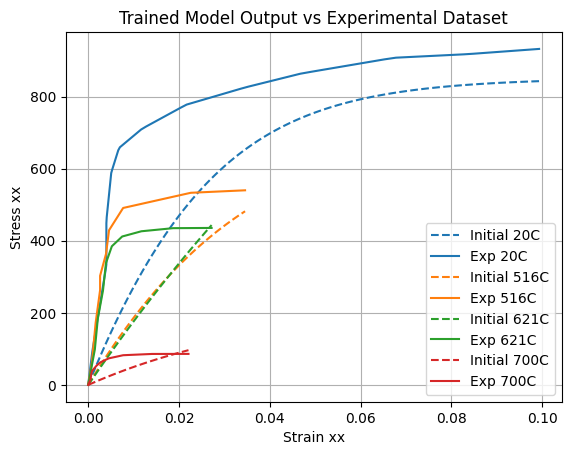

In [68]:
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))  # Celsius label for display
    plt.plot(loading[:, i, 0].detach().cpu(), res[:, i, 0].detach().cpu(), '--', color=f'C{i}',label=f"Initial {t_label}C")
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), color=f'C{i}',label=f'Exp {t_label}C')
plt.xlabel("Strain xx")
plt.ylabel("Stress xx")
plt.legend()
plt.grid()
plt.title("Trained Model Output vs Experimental Dataset")

In [69]:
print("Parameter Optimization Results:")
print("-" * 80)
for n, p in model.named_parameters():
    parts = n.split(".")
    if "parametrizations" in parts:
        param_idx = parts.index("parametrizations")
        simple_name = parts[param_idx - 1] + "." + parts[param_idx + 1]
    scaler = model_reparameterizer.map_dict[simple_name]
    final = scaler(p.data).cpu()
    print(f"\nParameter: {n}")
    print(f"  Initial:  {initial_params[simple_name].cpu()}")
    print(f"  Final:    {final}")
print("-" * 80)

Parameter Optimization Results:
--------------------------------------------------------------------------------

Parameter: discrete_equations.parametrizations.Bk_Y.original
  Initial:  tensor([0.0001, 0.0001, 0.0001, 0.0001])
  Final:    tensor([7.9803e-05, 1.0198e-04, 1.3439e-04, 1.1715e-04])

Parameter: discrete_equations.parametrizations.C_Y.original
  Initial:  tensor([46600., 27000., 21750.,  4300.])
  Final:    tensor([45654.0392, 28660.5817, 25344.1393,  6576.6532])

Parameter: discrete_equations.parametrizations.H_0_Y.original
  Initial:  tensor([0.5000, 0.5000, 0.5000, 0.5000])
  Final:    tensor([0.5076, 0.5010, 0.4885, 0.4935])

Parameter: discrete_equations.parametrizations.T_0_Y.original
  Initial:  tensor([234.5200, 631.3200, 715.3200, 778.5200])
  Final:    tensor([214.5450, 624.5055, 750.6060, 795.7997])

Parameter: discrete_equations.parametrizations.g_Y.original
  Initial:  tensor([50., 50., 50., 50.])
  Final:    tensor([43.6637, 32.9579, 13.1497, 26.3679])

Parame